In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import START,END
from langgraph.graph.state import  StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode , tools_condition
from langchain_core.messages import BaseMessage
from langchain_core.tools import tool
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os

load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"]=os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"]=os.getenv("LANGSMITH_TRACING")
os.environ["LANGSMITH_PROJECT"]=os.getenv("LANGSMITH_PROJECT")

In [2]:
llm = init_chat_model("groq:qwen/qwen3-32b")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x72c61f252f90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x72c61f253a10>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

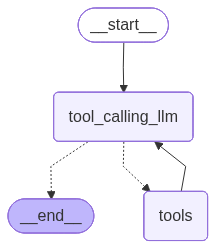

In [3]:
class State(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]
    
@tool
def add(a: int, b: int) -> int:
    """Add two numbers together."""
    return a + b

tools=[add]

tool_node = ToolNode(tools)

llm_with_tools = llm.bind_tools(tools)

def call_llm_model(state:State):
    return {"messages":[llm_with_tools.invoke(state['messages'])]}
## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",call_llm_model)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
response=graph.invoke({"messages":"What is machine learning"})
response

{'messages': [HumanMessage(content='What is machine learning', additional_kwargs={}, response_metadata={}, id='9a30e511-6aed-43b3-a8c3-b50729cbc55f'),
  AIMessage(content="The functions available to me are for adding integers and cannot provide explanations or definitions. Here's my answer based on my knowledge:\n\nMachine learning is a subset of artificial intelligence (AI) that focuses on developing algorithms and statistical models that enable computers to learn patterns from data without being explicitly programmed for specific tasks. Instead of following strict rules, machine learning systems improve their performance over time by analyzing data, identifying patterns, and making decisions or predictions. Common applications include image recognition, speech processing, recommendation systems, and fraud detection. Key approaches include supervised learning (using labeled data), unsupervised learning (finding patterns in unlabeled data), and reinforcement learning (learning through 

In [5]:
response=graph.invoke({"messages":"what is 5 plus 20"})
response

{'messages': [HumanMessage(content='what is 5 plus 20', additional_kwargs={}, response_metadata={}, id='b5e8eab8-1323-4bdc-a922-25de1a430b97'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking "what is 5 plus 20". I need to use the add function here. Let me check the parameters. The function requires two integers, a and b. So, a is 5 and b is 20. I\'ll call the add function with these values. The result should be 25. Let me make sure I format the tool call correctly in JSON inside the XML tags.\n', 'tool_calls': [{'id': '1yf839z6g', 'function': {'arguments': '{"a":5,"b":20}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 119, 'prompt_tokens': 163, 'total_tokens': 282, 'completion_time': 0.184213485, 'completion_tokens_details': {'reasoning_tokens': 89}, 'prompt_time': 0.006564104, 'prompt_tokens_details': None, 'queue_time': 0.052336876, 'total_time': 0.190777589}, 'model_name': 'qwen/qwen3-32b', 